In [4]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
%matplotlib inline

In [5]:
df=pd.read_csv('C:/Users/surug/OneDrive/Desktop/Projects/Covid19_Regression_Analysis/us_counties_covid19_daily.csv')
df

,date,county,state,fips,cases,deaths
0,2020-01-21,Snohomish,Washington,53061.0,1,0.0
1,2020-01-22,Snohomish,Washington,53061.0,1,0.0
2,2020-01-23,Snohomish,Washington,53061.0,1,0.0
3,2020-01-24,Cook,Illinois,17031.0,1,0.0
4,2020-01-24,Snohomish,Washington,53061.0,1,0.0
...,...,...,...,...,...,...
800432,2020-12-05,Sweetwater,Wyoming,56037.0,2098,10.0
800433,2020-12-05,Teton,Wyoming,56039.0,1739,2.0
800434,2020-12-05,Uinta,Wyoming,56041.0,1187,5.0
800435,2020-12-05,Washakie,Wyoming,56043.0,519,8.0


In [6]:
df['Date']=pd.to_datetime(df['date'])
df['Year']=df['Date'].dt.year
df['Month']=df['Date'].dt.month
df['Day']=df['Date'].dt.day
df1=df.drop('date',axis=1)
df1

,county,state,fips,cases,deaths,Date,Year,Month,Day
0,Snohomish,Washington,53061.0,1,0.0,2020-01-21,2020,1,21
1,Snohomish,Washington,53061.0,1,0.0,2020-01-22,2020,1,22
2,Snohomish,Washington,53061.0,1,0.0,2020-01-23,2020,1,23
3,Cook,Illinois,17031.0,1,0.0,2020-01-24,2020,1,24
4,Snohomish,Washington,53061.0,1,0.0,2020-01-24,2020,1,24
...,...,...,...,...,...,...,...,...,...
800432,Sweetwater,Wyoming,56037.0,2098,10.0,2020-12-05,2020,12,5
800433,Teton,Wyoming,56039.0,1739,2.0,2020-12-05,2020,12,5
800434,Uinta,Wyoming,56041.0,1187,5.0,2020-12-05,2020,12,5
800435,Washakie,Wyoming,56043.0,519,8.0,2020-12-05,2020,12,5


In [7]:
df1.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 800437 entries, 0 to 800436
Data columns (total 9 columns):
 #   Column  Non-Null Count   Dtype         
---  ------  --------------   -----         
 0   county  800437 non-null  object        
 1   state   800437 non-null  object        
 2   fips    792846 non-null  float64       
 3   cases   800437 non-null  int64         
 4   deaths  783704 non-null  float64       
 5   Date    800437 non-null  datetime64[ns]
 6   Year    800437 non-null  int32         
 7   Month   800437 non-null  int32         
 8   Day     800437 non-null  int32         
dtypes: datetime64[ns](1), float64(2), int32(3), int64(1), object(2)
memory usage: 45.8+ MB


In [8]:
df1.columns

Index(['county', 'state', 'fips', 'cases', 'deaths', 'Date', 'Year', 'Month',
       'Day'],
      dtype='object')

In [9]:
df1['county'].unique()

array(['Snohomish', 'Cook', 'Orange', ..., 'Skagway Municipality',
       'Esmeralda', 'Loving'], dtype=object)

In [10]:
df1['county'].shape

(800437,)

In [11]:
df1['state'].unique()

array(['Washington', 'Illinois', 'California', 'Arizona', 'Massachusetts',
       'Wisconsin', 'Texas', 'Nebraska', 'Utah', 'Oregon', 'Florida',
       'New York', 'Rhode Island', 'Georgia', 'New Hampshire',
       'North Carolina', 'New Jersey', 'Colorado', 'Maryland', 'Nevada',
       'Tennessee', 'Hawaii', 'Indiana', 'Kentucky', 'Minnesota',
       'Oklahoma', 'Pennsylvania', 'South Carolina',
       'District of Columbia', 'Kansas', 'Missouri', 'Vermont',
       'Virginia', 'Connecticut', 'Iowa', 'Louisiana', 'Ohio', 'Michigan',
       'South Dakota', 'Arkansas', 'Delaware', 'Mississippi',
       'New Mexico', 'North Dakota', 'Wyoming', 'Alaska', 'Maine',
       'Alabama', 'Idaho', 'Montana', 'Puerto Rico', 'Virgin Islands',
       'Guam', 'West Virginia', 'Northern Mariana Islands'], dtype=object)

In [12]:
df1['state'].shape

(800437,)

In [13]:
df1['fips'].unique()

array([53061., 17031.,  6059., ...,  2230., 32009., 48301.])

In [14]:
df1['cases'].unique()

array([    1,     2,    10, ..., 77390, 16329, 30414])

In [15]:
df1['deaths'].unique()

array([0.0000e+00, 1.0000e+00, 3.0000e+00, ..., 2.2690e+03, 2.4346e+04,
       3.0600e+03])

In [16]:
df1['Date'].shape

(800437,)

In [17]:
df1['Year'].unique()

array([2020], dtype=int32)

In [18]:
df1['Month'].unique()

array([ 1,  2,  3,  4,  5,  6,  7,  8,  9, 10, 11, 12], dtype=int32)

In [19]:
df1['Day'].unique()

array([21, 22, 23, 24, 25, 26, 27, 28, 29, 30, 31,  1,  2,  3,  4,  5,  6,
        7,  8,  9, 10, 11, 12, 13, 14, 15, 16, 17, 18, 19, 20],
      dtype=int32)

In [20]:
df1.head(2)

,county,state,fips,cases,deaths,Date,Year,Month,Day
0,Snohomish,Washington,53061.0,1,0.0,2020-01-21,2020,1,21
1,Snohomish,Washington,53061.0,1,0.0,2020-01-22,2020,1,22


In [21]:
df1.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 800437 entries, 0 to 800436
Data columns (total 9 columns):
 #   Column  Non-Null Count   Dtype         
---  ------  --------------   -----         
 0   county  800437 non-null  object        
 1   state   800437 non-null  object        
 2   fips    792846 non-null  float64       
 3   cases   800437 non-null  int64         
 4   deaths  783704 non-null  float64       
 5   Date    800437 non-null  datetime64[ns]
 6   Year    800437 non-null  int32         
 7   Month   800437 non-null  int32         
 8   Day     800437 non-null  int32         
dtypes: datetime64[ns](1), float64(2), int32(3), int64(1), object(2)
memory usage: 45.8+ MB


<Axes: xlabel='Year', ylabel='count'>

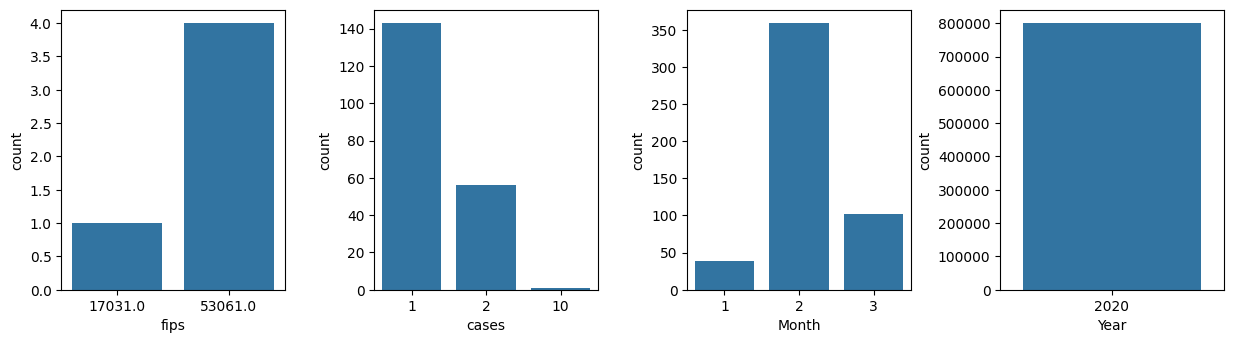

In [22]:
plt.figure(1,figsize=(15,8))
plt.subplots_adjust(wspace=0.4,hspace=0.2)

plt.subplot(241)
sns.countplot(x='fips', data=df1.head())

plt.subplot(242)
sns.countplot(x='cases', data=df1.head(200))

plt.subplot(243)
sns.countplot(x='Month',data=df1.head(500))

plt.subplot(244)
sns.countplot(x='Year',data=df1)

<Axes: xlabel='state', ylabel='count'>

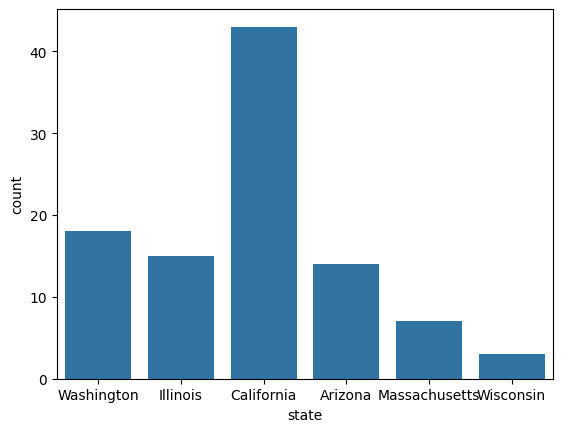

In [23]:
sns.countplot(x='state',data=df1.head(100))

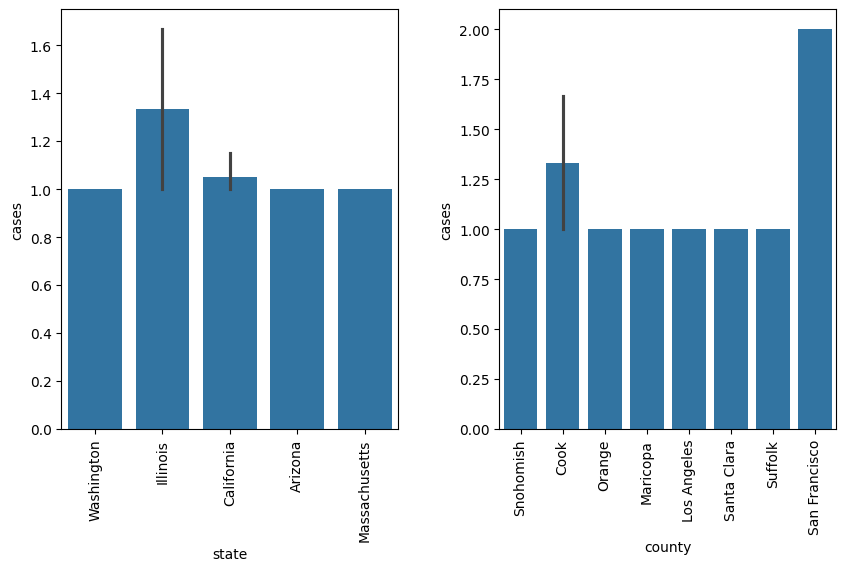

In [24]:
plt.figure(figsize=(10,12))
plt.subplots_adjust(wspace=0.3)

plt.subplot(221)
sns.barplot(x='state',y='cases',data=df1.head(50))
plt.xticks(rotation=90);

plt.subplot(222)
sns.barplot(x='county',y='cases',data=df1.head(50))
plt.xticks(rotation=90);

In [25]:
df1['county'].unique()

array(['Snohomish', 'Cook', 'Orange', ..., 'Skagway Municipality',
       'Esmeralda', 'Loving'], dtype=object)

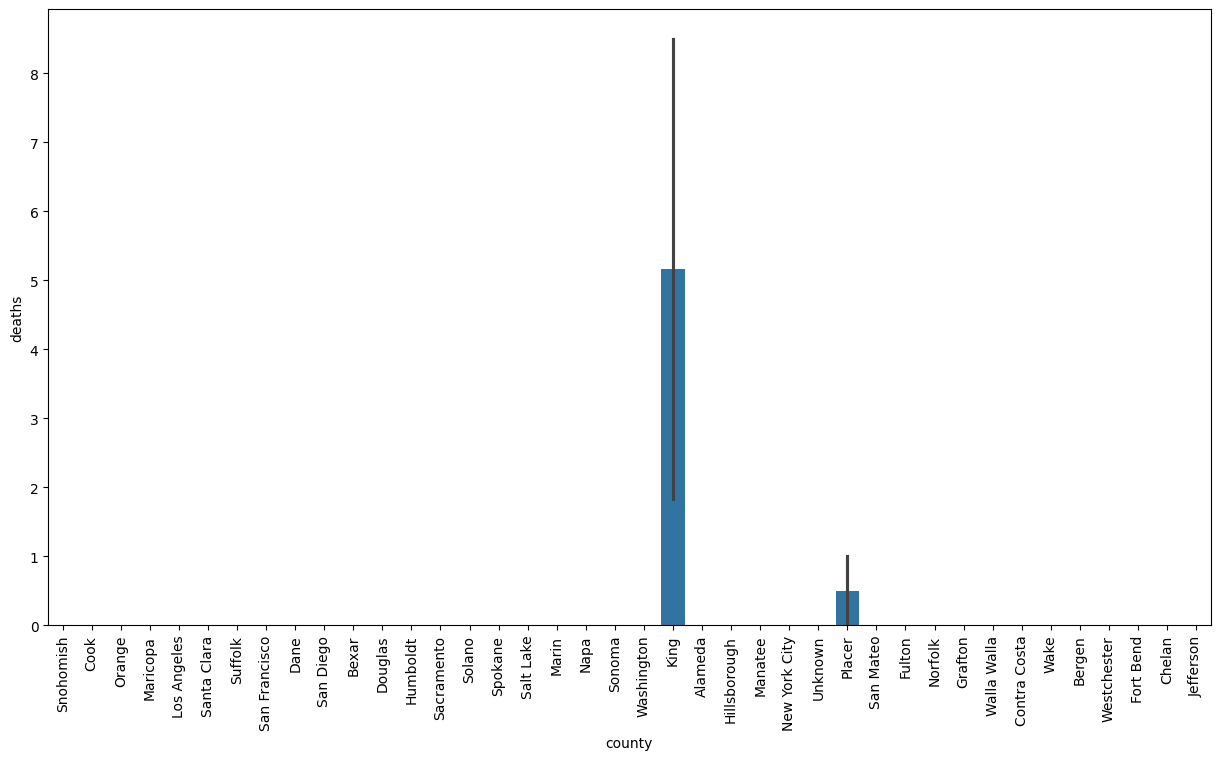

In [26]:
plt.figure(figsize=(15,8))
sns.barplot(x='county',y='deaths',data=df1.head(550))
plt.xticks(rotation=90);

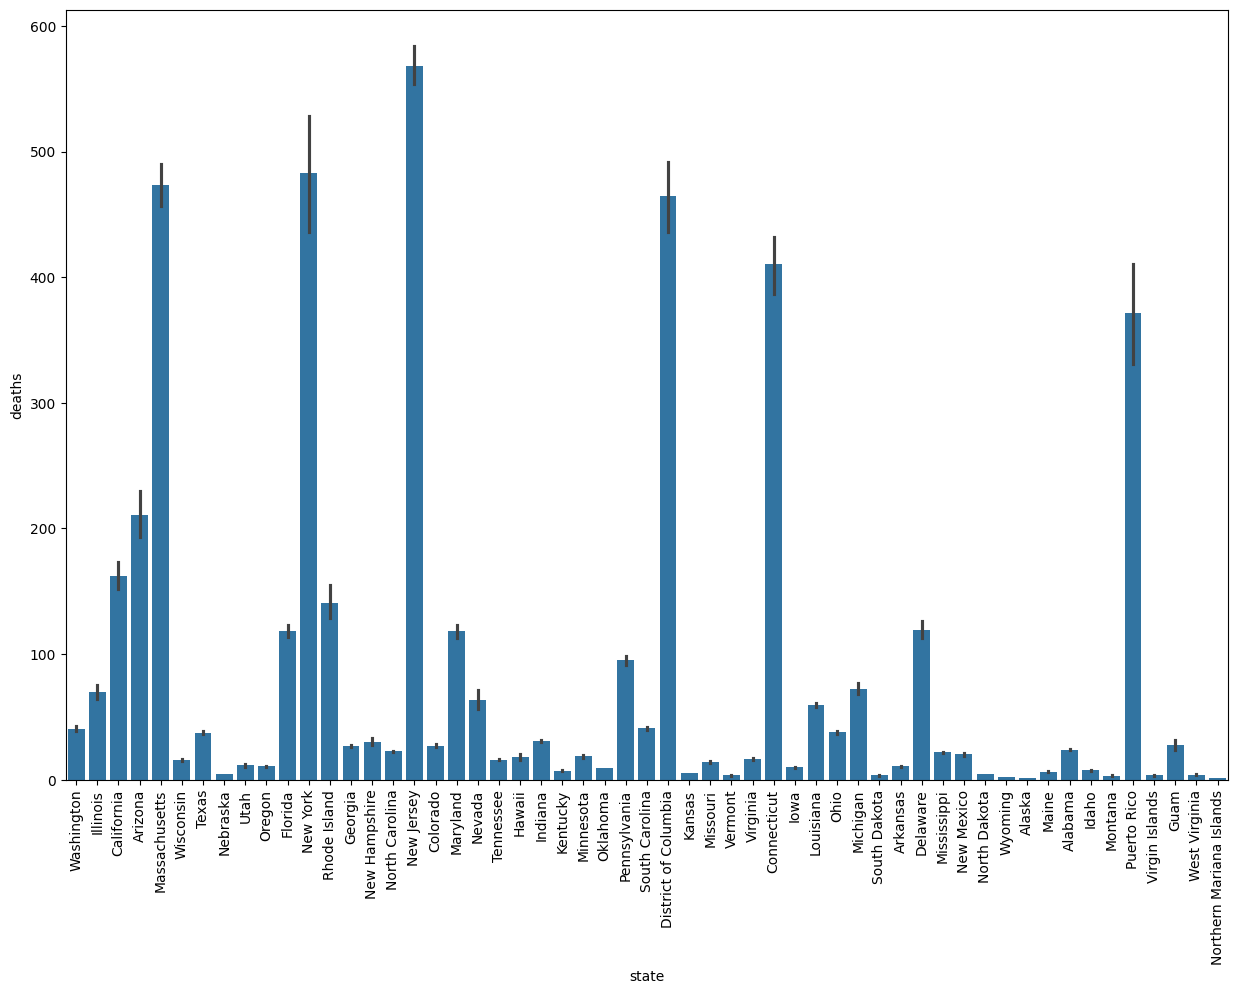

In [27]:
plt.figure(figsize=(15,10))
sns.barplot(x='state',y='deaths',data=df1)
plt.xticks(rotation=90);

In [28]:
df2=df1.sort_values('deaths',ascending=True)

Text(0.5, 1.0, 'Day VS Deaths Graph')

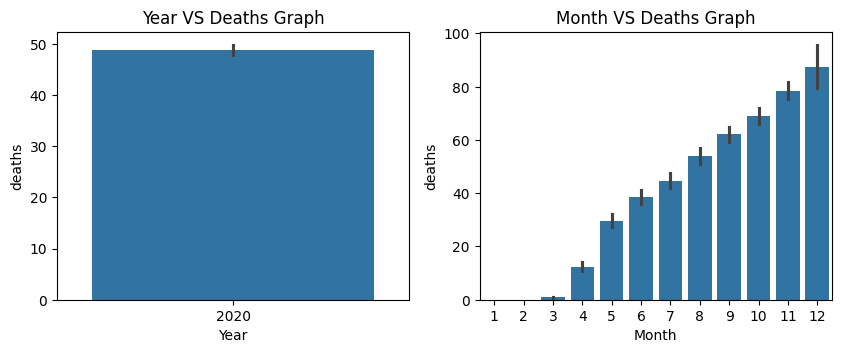

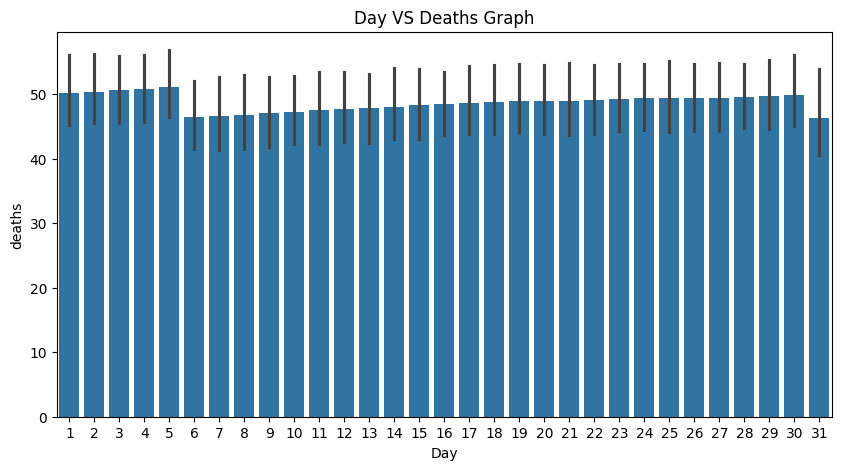

In [29]:
plt.figure(figsize=(10,8))
plt.subplots_adjust(wspace=0.2,hspace=0.3)

plt.subplot(221)
sns.barplot(x='Year',y='deaths',data=df1)
plt.title('Year VS Deaths Graph')

plt.subplot(222)
sns.barplot(x='Month',y='deaths',data=df2)
plt.title('Month VS Deaths Graph')

plt.figure(figsize=(10,5))
sns.barplot(x='Day',y='deaths',data=df1)
plt.title('Day VS Deaths Graph')

Text(0.5, 1.0, 'Day VS Cases Graph')

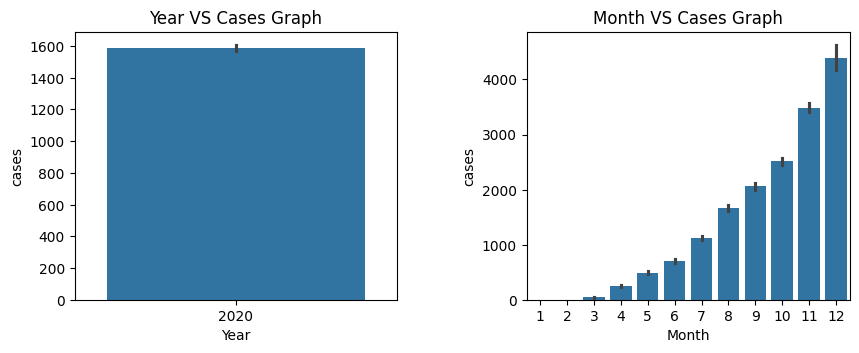

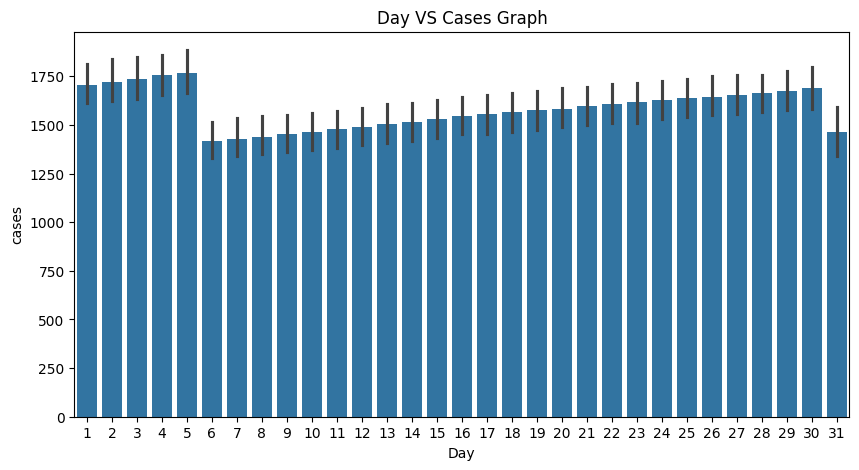

In [30]:
plt.figure(figsize=(10,8))
plt.subplots_adjust(hspace=0.3,wspace=0.4)

plt.subplot(221)
sns.barplot(x='Year',y='cases',data=df1)
plt.title('Year VS Cases Graph')

plt.subplot(222)
sns.barplot(x='Month',y='cases',data=df1)
plt.title('Month VS Cases Graph')


plt.figure(figsize=(10,5))
sns.barplot(x='Day',y='cases',data=df1)
plt.title('Day VS Cases Graph')

In [31]:
from sklearn.preprocessing import LabelEncoder

In [32]:
for i in df1.columns:
    if df1[i].dtypes == 'object':
        lb=LabelEncoder()
        df1[i]=lb.fit_transform(df1[i])
df1   

,county,state,fips,cases,deaths,Date,Year,Month,Day
0,1599,51,53061.0,1,0.0,2020-01-21,2020,1,21
1,1599,51,53061.0,1,0.0,2020-01-22,2020,1,22
2,1599,51,53061.0,1,0.0,2020-01-23,2020,1,23
3,414,14,17031.0,1,0.0,2020-01-24,2020,1,24
4,1599,51,53061.0,1,0.0,2020-01-24,2020,1,24
...,...,...,...,...,...,...,...,...,...
800432,1681,54,56037.0,2098,10.0,2020-12-05,2020,12,5
800433,1706,54,56039.0,1739,2.0,2020-12-05,2020,12,5
800434,1763,54,56041.0,1187,5.0,2020-12-05,2020,12,5
800435,1826,54,56043.0,519,8.0,2020-12-05,2020,12,5


In [33]:
x=df1.drop(['deaths','Date'],axis=1)
x=x.fillna(0.0)
y=df1['deaths']
y=y.fillna(0.0)

In [34]:
x.isnull().sum()

county    0
state     0
fips      0
cases     0
Year      0
Month     0
Day       0
dtype: int64

In [35]:
y.isnull().sum()

np.int64(0)

In [36]:
!pip install prettytable


You should consider upgrading via the 'C:\Users\surug\AppData\Local\Programs\Python\Python39\python.exe -m pip install --upgrade pip' command.


In [38]:
from prettytable import PrettyTable

In [39]:
import sklearn
print(sklearn.__version__)


1.6.1


In [40]:
pip install --upgrade scikit-learn


Note: you may need to restart the kernel to use updated packages.


You should consider upgrading via the 'C:\Users\surug\AppData\Local\Programs\Python\Python39\python.exe -m pip install --upgrade pip' command.


In [41]:
models_results_rmse = {}
models_results_r2 = {}
def evaluate(y_t, y_p, title):
    table = PrettyTable()
    table.field_names = ['Metric', 'Value']
    rmse = mean_squared_error(y_t, y_p, squared=False).round(4)
    r2 = r2_score(y_t, y_p).round(4)
    
    table.add_row(['RMSE', rmse])
    table.add_row(['R2 Score', r2])
    
    models_results_rmse[title] = rmse
    models_results_r2[title] = r2
    print(table)

In [42]:
from sklearn.metrics import mean_squared_error, r2_score
from prettytable import PrettyTable
import numpy as np

def evaluate(y_t, y_p, title="Model Evaluation"):
    table = PrettyTable()
    table.field_names = ['Metric', 'Value']

    try:
        # For scikit-learn >= 0.22
        rmse = mean_squared_error(y_t, y_p, squared=False).round(4)
    except TypeError:
        # For older versions
        rmse = np.sqrt(mean_squared_error(y_t, y_p)).round(4)

    r2 = round(r2_score(y_t, y_p), 4)
    table.add_row(['RMSE', rmse])
    table.add_row(['R2 Score', r2])

    models_results_rmse[title] = rmse
    models_results_r2[title] = r2
    print(table)


In [43]:
from sklearn.model_selection import train_test_split
x_train,x_test,y_train,y_test=train_test_split(x,y,test_size=0.3,random_state=0)

In [44]:
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error, r2_score

modelLR = LinearRegression() 
modelLR.fit(x_train, y_train)
# y_pred = modelLR.predict(x_test)

LinearRegression()

In [45]:
modelLR.score(x_train,y_train)

0.611566225677375

In [46]:
y_pred = modelLR.predict(x_test)

In [47]:
r2_score(y_test,y_pred)

0.6134642532921344

In [48]:
mean_squared_error(y_test,y_pred)

70886.27732719247

In [49]:
evaluate(y_test,y_pred,title='LinearRegression')

+----------+----------+
|  Metric  |  Value   |
+----------+----------+
|   RMSE   | 266.2448 |
| R2 Score |  0.6135  |
+----------+----------+


In [50]:
from sklearn.tree import DecisionTreeRegressor

modelDTR = DecisionTreeRegressor(max_depth=3)
modelDTR.fit(x_train, y_train)

DecisionTreeRegressor(max_depth=3)

In [51]:
modelDTR.score(x_train, y_train)

0.9107303675264574

In [52]:
y_predDTR=modelDTR.predict(x_test)

In [53]:
r2_score(y_test,y_predDTR)

0.9022369611121539

In [54]:
mean_squared_error(y_test,y_predDTR)

17928.63388697277

In [55]:
evaluate(y_test,y_predDTR,title='DecisionTreeRegressor')

+----------+----------+
|  Metric  |  Value   |
+----------+----------+
|   RMSE   | 133.8978 |
| R2 Score |  0.9022  |
+----------+----------+


In [56]:
x=x.head(10000)
y=y.head(10000)
from sklearn.model_selection import train_test_split
x_train,x_test,y_train,y_test=train_test_split(x,y,test_size=0.3,random_state=0)

In [57]:
from sklearn.ensemble import RandomForestRegressor

modelRFR = RandomForestRegressor(max_depth=5)
modelRFR.fit(x_train, y_train)



RandomForestRegressor(max_depth=5)

In [58]:
modelRFR.score(x_train,y_train)

0.9404358009706182

In [59]:
y_predRFR=modelRFR.predict(x_test)

In [60]:
r2_score(y_test,y_predRFR)

0.8645851098801258

In [61]:
mean_squared_error(y_test,y_predRFR)

1.8445252027650618

In [62]:
evaluate(y_test,y_predRFR,title='RandomForestRegressor')

+----------+--------+
|  Metric  | Value  |
+----------+--------+
|   RMSE   | 1.3581 |
| R2 Score | 0.8646 |
+----------+--------+


In [63]:
from sklearn.svm import SVR

modelSVR = SVR()
modelSVR.fit(x_train, y_train)

SVR()

In [64]:
modelSVR.score(x_train, y_train)

0.000774901748877177

In [65]:
y_predSVR=modelSVR.predict(x_test)

In [66]:
r2_score(y_test,y_predSVR)

0.003969940064210364

In [67]:
mean_squared_error(y_test,y_predSVR)

13.567212192372642

In [68]:
evaluate(y_test,y_predSVR,title='SVR')

+----------+--------+
|  Metric  | Value  |
+----------+--------+
|   RMSE   | 3.6834 |
| R2 Score | 0.004  |
+----------+--------+


In [69]:
!pip install xgboost


You should consider upgrading via the 'C:\Users\surug\AppData\Local\Programs\Python\Python39\python.exe -m pip install --upgrade pip' command.


In [71]:
pip install --upgrade scikit-learn xgboost


Note: you may need to restart the kernel to use updated packages.Requirement already satisfied: scikit-learn in c:\users\surug\appdata\local\programs\python\python39\lib\site-packages (1.6.1)



You should consider upgrading via the 'C:\Users\surug\AppData\Local\Programs\Python\Python39\python.exe -m pip install --upgrade pip' command.


In [72]:
import warnings
warnings.filterwarnings("ignore", category=FutureWarning)


In [77]:
import sklearn
import xgboost
print("Scikit-learn version:", sklearn.__version__)
print("XGBoost version:", xgboost.__version__)


Scikit-learn version: 1.6.1
XGBoost version: 2.1.3


In [84]:
from xgboost import XGBRegressor

class PatchedXGBRegressor(XGBRegressor):
    def __sklearn_tags__(self):
        return self._get_tags()  # Reuse the old tag mechanism

model = PatchedXGBRegressor()


In [85]:
from xgboost import XGBRegressor
modelXGB = XGBRegressor()
modelXGB.fit(x_train, y_train)

XGBRegressor(base_score=None, booster=None, callbacks=None,
             colsample_bylevel=None, colsample_bynode=None,
             colsample_bytree=None, device=None, early_stopping_rounds=None,
             enable_categorical=False, eval_metric=None, feature_types=None,
             gamma=None, grow_policy=None, importance_type=None,
             interaction_constraints=None, learning_rate=None, max_bin=None,
             max_cat_threshold=None, max_cat_to_onehot=None,
             max_delta_step=None, max_depth=None, max_leaves=None,
             min_child_weight=None, missing=nan, monotone_constraints=None,
             multi_strategy=None, n_estimators=None, n_jobs=None,
             num_parallel_tree=None, random_state=None, ...)

In [86]:
modelXGB.score(x_train, y_train)

0.997989344624234

In [87]:
y_predXGB=modelXGB.predict(x_test)

In [88]:
r2_score(y_test,y_predXGB)

0.9407983069406997

In [89]:
mean_squared_error(y_test,y_predXGB)

0.806403304670365

In [90]:
evaluate(y_test,y_predXGB,title='XGBRegressor')

+----------+--------+
|  Metric  | Value  |
+----------+--------+
|   RMSE   | 0.898  |
| R2 Score | 0.9408 |
+----------+--------+


In [91]:
imp_fea1=modelLR.coef_[modelLR.coef_>0]
imp_fea1

array([4.68031137e-04, 5.38333463e+00, 4.04564113e-02, 7.54951657e-15])

In [92]:
coef=pd.DataFrame(modelLR.coef_,index=x.columns,columns=['coefficient'])
coef[coef>0.0]

,coefficient
county,4.680311e-04
state,5.383335e+00
fips,NaN
cases,4.045641e-02
Year,7.549517e-15
Month,NaN
Day,NaN


In [93]:
df2=df1[['state','cases','Month']]
df2.head()

,state,cases,Month
0,51,1,1
1,51,1,1
2,51,1,1
3,14,1,1
4,51,1,1


In [94]:
fea_imp2=modelDTR.feature_importances_[modelDTR.feature_importances_>0]
fea_imp2

array([0.23173665, 0.76826335])

In [95]:
coef=pd.DataFrame(modelDTR.feature_importances_,index=x.columns,columns=['coefficient'])
coef[coef>0.0]

,coefficient
county,NaN
state,NaN
fips,0.231737
cases,0.768263
Year,NaN
Month,NaN
Day,NaN


In [96]:
df3=df1[['fips','cases']]
df3.head()

,fips,cases
0,53061.0,1
1,53061.0,1
2,53061.0,1
3,17031.0,1
4,53061.0,1


In [97]:
imp_fea3=modelRFR.feature_importances_[modelRFR.feature_importances_>0]
imp_fea3

array([0.04889788, 0.07937038, 0.07503223, 0.71908657, 0.07761294])

In [98]:
coef=pd.DataFrame(modelRFR.feature_importances_,index=x.columns,columns=['coefficient'])
coef

,coefficient
county,0.048898
state,0.079370
fips,0.075032
cases,0.719087
Year,0.000000
Month,0.000000
Day,0.077613


In [99]:
df4=df1[['county','state','fips','cases','Day']]
df4.head()

,county,state,fips,cases,Day
0,1599,51,53061.0,1,21
1,1599,51,53061.0,1,22
2,1599,51,53061.0,1,23
3,414,14,17031.0,1,24
4,1599,51,53061.0,1,24


In [100]:
imp_fea4=modelXGB.feature_importances_[modelXGB.feature_importances_>0]
imp_fea4

array([8.5469812e-02, 3.3746615e-01, 3.8759481e-02, 4.9011347e-01,
       1.0205315e-04, 4.8089035e-02], dtype=float32)

In [101]:
coef=pd.DataFrame(modelXGB.feature_importances_,index=x.columns,columns=['coefficient'])
coef

,coefficient
county,0.085470
state,0.337466
fips,0.038759
cases,0.490113
Year,0.000000
Month,0.000102
Day,0.048089


In [102]:
df5=df1[['county','state','fips','cases','Month','Day']]
df5.head()

,county,state,fips,cases,Month,Day
0,1599,51,53061.0,1,1,21
1,1599,51,53061.0,1,1,22
2,1599,51,53061.0,1,1,23
3,414,14,17031.0,1,1,24
4,1599,51,53061.0,1,1,24


In [103]:
impdf=df1[['fips','cases','Month','Day']]
impdf=impdf.fillna(0.0).head(10000)

In [104]:
x_train,x_test,y_train,y_test=train_test_split(impdf,y,random_state=0)
modelLR.fit(x_train,y_train)

LinearRegression()

In [105]:
modelLR.score(x_train,y_train)

0.5311958260880805

In [107]:
modelLR.score(x_test,y_test)

0.745320730778437

In [108]:
modelXGB.fit(x_train,y_train)

XGBRegressor(base_score=None, booster=None, callbacks=None,
             colsample_bylevel=None, colsample_bynode=None,
             colsample_bytree=None, device=None, early_stopping_rounds=None,
             enable_categorical=False, eval_metric=None, feature_types=None,
             gamma=None, grow_policy=None, importance_type=None,
             interaction_constraints=None, learning_rate=None, max_bin=None,
             max_cat_threshold=None, max_cat_to_onehot=None,
             max_delta_step=None, max_depth=None, max_leaves=None,
             min_child_weight=None, missing=nan, monotone_constraints=None,
             multi_strategy=None, n_estimators=None, n_jobs=None,
             num_parallel_tree=None, random_state=None, ...)

In [109]:
modelXGB.score(x_train,y_train)


0.9963207923899051

In [110]:
modelXGB.score(x_test,y_test)

0.9431346287164364

In [111]:
y_predXGB=modelXGB.predict(x_test)

In [112]:
r2_score(y_test,y_predXGB)

0.9431346287164364

In [113]:
colors = ['#F0D290','#DE834D','#A3423C','#781D42']
colors2 = ['#F0D290','#DE834D','#A3423C','#781D42','#671E31']
colors3 = ['#f0d290','#e9c083','#e2af77','#d99d6d','#d08c64', '#c67b5d',
           '#bc6b56','#b05a51','#a34b4d','#963b49', '#872c45','#781d42']

<Figure size 2000x800 with 0 Axes>

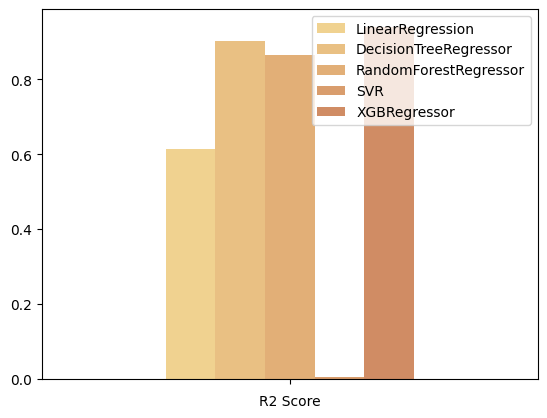

In [115]:
plt.figure(figsize=(20, 8))
pd.DataFrame(models_results_r2, index=['']).plot.bar(color=colors3);
plt.xlabel('R2 Score');

<Figure size 2000x800 with 0 Axes>

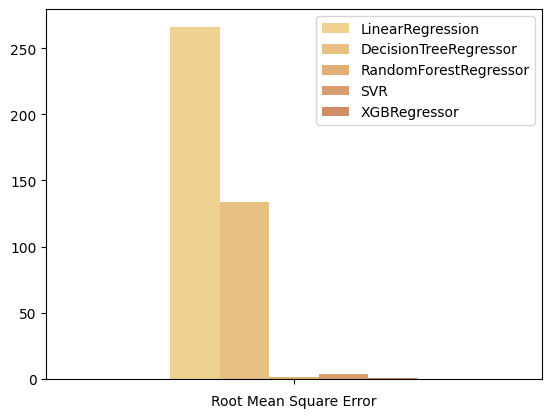

In [116]:
plt.figure(figsize=(20, 8))
pd.DataFrame(models_results_rmse, index=['']).plot.bar(color=colors3);
plt.xlabel('Root Mean Square Error');

In [117]:
models_results_rmse

{'LinearRegression': np.float64(266.2448),
 'DecisionTreeRegressor': np.float64(133.8978),
 'RandomForestRegressor': np.float64(1.3581),
 'SVR': np.float64(3.6834),
 'XGBRegressor': np.float64(0.898)}

In [118]:
df1.head()

,county,state,fips,cases,deaths,Date,Year,Month,Day
0,1599,51,53061.0,1,0.0,2020-01-21,2020,1,21
1,1599,51,53061.0,1,0.0,2020-01-22,2020,1,22
2,1599,51,53061.0,1,0.0,2020-01-23,2020,1,23
3,414,14,17031.0,1,0.0,2020-01-24,2020,1,24
4,1599,51,53061.0,1,0.0,2020-01-24,2020,1,24


In [119]:
df1.isnull().sum()

county        0
state         0
fips       7591
cases         0
deaths    16733
Date          0
Year          0
Month         0
Day           0
dtype: int64

In [120]:
df1=df1.fillna(0.0)

In [121]:
df1.isnull().sum()

county    0
state     0
fips      0
cases     0
deaths    0
Date      0
Year      0
Month     0
Day       0
dtype: int64

In [122]:
df1['Year'].unique()

array([2020], dtype=int32)

In [123]:
def plot_forecasted_sales(y_pred, y_train, y_true=[], period=5, title=''):
    
    # plot
    plt.figure(figsize=(20, 8))
    plt.plot(y_train.to_list(), color=colors[0])
    plt.plot([None for i in y_train] + [x for x in y_pred], color=colors[2])
    
    # set legend
    if len(y_true) > 0:
        plt.plot([None for i in y_train] + [x for x in y_true], color=colors[1])
        plt.legend(['2020-2021 Acual cases', '2022 Acual cases', f'2022 Forecasted cases \
(RMSE = {mean_squared_error(y_true, y_pred, squared=False).round(1)}, R2 = {r2_score(y_true, y_pred).round(3)})'])
    else:
        plt.legend(['2020-2022 Actual cases', '2020-2022 Forecasted cases'])
    
    # set parameters
    plt.xticks(range(0, len(y_train) + len(y_pred), period), rotation=75)
    plt.xlabel('Week')
    plt.ylabel('cases')
    plt.title(title)
    plt.show()

In [124]:
df1
x=df1.drop(['deaths','Date'],axis=1)

In [125]:
from sklearn.preprocessing import MinMaxScaler
scaler = MinMaxScaler()
df_scaled = scaler.fit_transform(x.to_numpy())
df_scaled
df_scaled = pd.DataFrame(df_scaled, columns=['county', 'state', 'fips', 'cases','Year','Month','Day'])
df_scaled

,county,state,fips,cases,Year,Month,Day
0,0.829357,0.944444,0.680008,0.000002,0.0,0.0,0.666667
1,0.829357,0.944444,0.680008,0.000002,0.0,0.0,0.700000
2,0.829357,0.944444,0.680008,0.000002,0.0,0.0,0.733333
3,0.214730,0.259259,0.218262,0.000002,0.0,0.0,0.766667
4,0.829357,0.944444,0.680008,0.000002,0.0,0.0,0.766667
...,...,...,...,...,...,...,...
800432,0.871888,1.000000,0.718147,0.004773,0.0,1.0,0.133333
800433,0.884855,1.000000,0.718172,0.003956,0.0,1.0,0.133333
800434,0.914419,1.000000,0.718198,0.002701,0.0,1.0,0.133333
800435,0.947095,1.000000,0.718224,0.001181,0.0,1.0,0.133333


In [126]:
df_scaled['fips']=df_scaled['fips'].fillna(0.0)

In [127]:
df_scaled['fips'].hasnans

False

In [128]:
df.iloc[6994:,-5]

6994       0.0
6995       0.0
6996       0.0
6997       0.0
6998       0.0
          ... 
800432    10.0
800433     2.0
800434     5.0
800435     8.0
800436     2.0
Name: deaths, Length: 793443, dtype: float64

In [129]:
x=x.head(10000)
y=y.head(10000)
from sklearn.model_selection import train_test_split
x_train,x_test,y_train,y_test=train_test_split(x,y,test_size=0.3,random_state=0)
from xgboost import XGBRegressor
modelXGB = XGBRegressor()
modelXGB.fit(x_train, y_train)

XGBRegressor(base_score=None, booster=None, callbacks=None,
             colsample_bylevel=None, colsample_bynode=None,
             colsample_bytree=None, device=None, early_stopping_rounds=None,
             enable_categorical=False, eval_metric=None, feature_types=None,
             gamma=None, grow_policy=None, importance_type=None,
             interaction_constraints=None, learning_rate=None, max_bin=None,
             max_cat_threshold=None, max_cat_to_onehot=None,
             max_delta_step=None, max_depth=None, max_leaves=None,
             min_child_weight=None, missing=nan, monotone_constraints=None,
             multi_strategy=None, n_estimators=None, n_jobs=None,
             num_parallel_tree=None, random_state=None, ...)

In [130]:
y_pred = modelXGB.predict(df_scaled)[:100]
y_test = df.iloc[6994:,-5][:100]

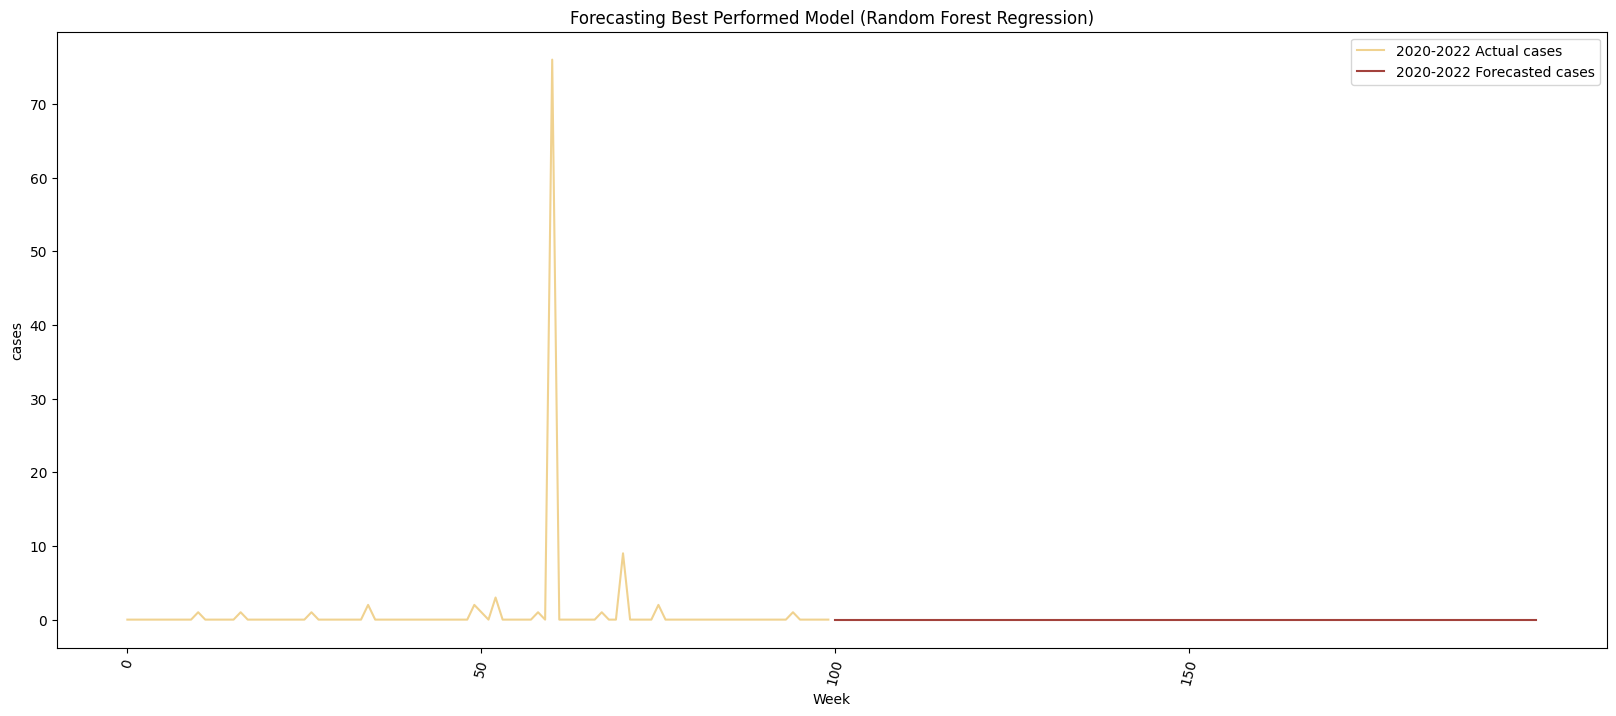

In [131]:
plot_forecasted_sales(y_train=y_test, y_pred=y_pred, period=50, title='Forecasting Best Performed Model (Random Forest Regression)')